# Superstore Sales Analysis

## Business Performance Analysis

This notebook summarizes sales, profit, and margin by **category, segment, sub-category, region, and city** using the cleaned Superstore dataset (9,977 rows). The detailed exploratory analysis (discounts, states) is in `02_Exploratory_Data_Analysis.ipynb`, and the business queries are in `sql/superstore_analysis.sql`.

## 1. Load the Cleaned Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_excel('../data/Cleaned/Superstore_Cleaned.xlsx')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9977, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 2. Data Checks

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


**Result:** all 13 columns have the expected data types and there are **no missing values**.

## 3. Overall Business Performance

In [3]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
avg_sales = df['Sales'].mean()
avg_profit = df['Profit'].mean()
avg_discount = df['Discount'].mean()
profit_margin = (total_profit / total_sales) * 100

print("OVERALL BUSINESS PERFORMANCE")
print("=" * 40)
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Average Sales per Row: ${avg_sales:,.2f}")
print(f"Average Profit per Row: ${avg_profit:,.2f}")
print(f"Average Discount: {avg_discount:.2%}")
print(f"Profit Margin: {profit_margin:.2f}%")

OVERALL BUSINESS PERFORMANCE
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Total Quantity: 37,820
Average Sales per Row: $230.15
Average Profit per Row: $28.69
Average Discount: 15.63%
Profit Margin: 12.47%


**Insight:** the business generated about **$2.30M in sales** and **$286K in profit**, an overall margin of **12.47%**. The average discount is **15.63%**. Averages are per row (order line), because the dataset has no Order ID.

## 4. Category Analysis

          Category        Sales       Profit  Quantity  Profit_Margin
0        Furniture  741306.3133   18421.8137      8020           2.49
1  Office Supplies  718735.2440  122364.6608     22861          17.02
2       Technology  836154.0330  145454.9481      6939          17.40


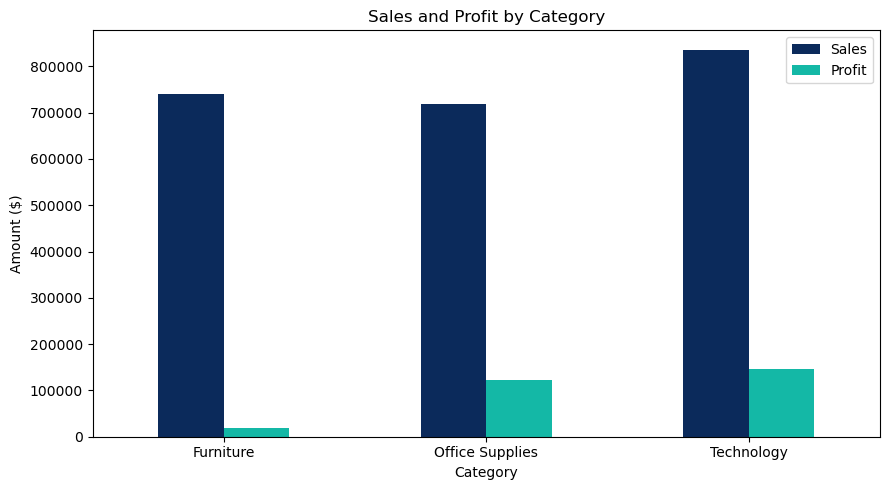

In [4]:
category_analysis = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

category_analysis['Profit_Margin'] = (
    category_analysis['Profit'] /
    category_analysis['Sales'] * 100
).round(2)

print(category_analysis)

# Visualization
category_analysis.plot(
    x='Category',
    y=['Sales', 'Profit'],
    kind='bar',
    figsize=(9, 5),
    color=['#0B2A5B', '#14B8A6']
)

plt.title('Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** **Technology** has the highest sales ($836K) and profit ($145K) with a **17.40%** margin. **Furniture** sells almost as much as Office Supplies ($741K) but earns only **2.49%**, while **Office Supplies** earns **17.02%**.

## 5. Segment Analysis

,Segment,Sales,Profit,Quantity,Sales_Share,Profit_Margin
0,Consumer,1160832.77,134007.44,19497,50.55,11.54
1,Corporate,706070.13,91954.98,11591,30.75,13.02
2,Home Office,429292.68,60279.00,6732,18.70,14.04


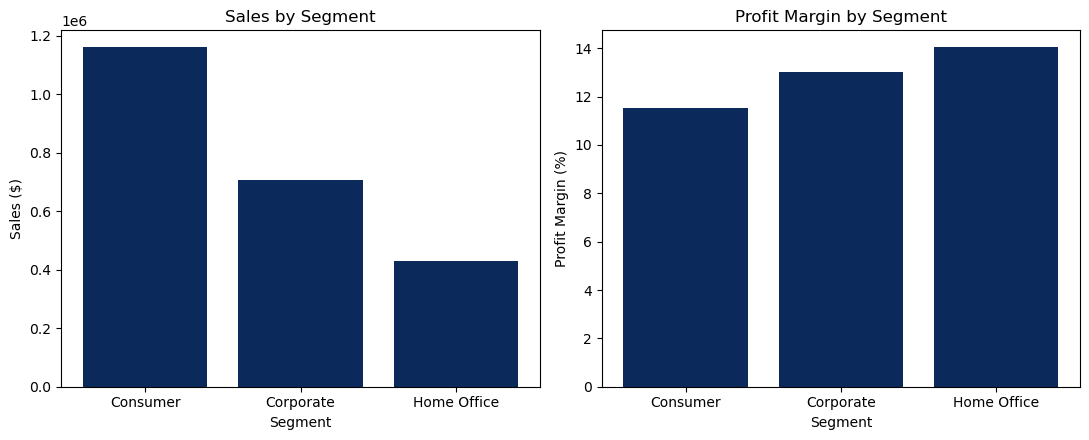

In [5]:
segment_analysis = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

segment_analysis['Sales_Share'] = (
    segment_analysis['Sales'] /
    total_sales * 100
).round(2)

segment_analysis['Profit_Margin'] = (
    segment_analysis['Profit'] /
    segment_analysis['Sales'] * 100
).round(2)

display(segment_analysis.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(segment_analysis['Segment'], segment_analysis['Sales'], color='#0B2A5B')
axes[0].set_title('Sales by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(segment_analysis['Segment'], segment_analysis['Profit_Margin'], color='#0B2A5B')
axes[1].set_title('Profit Margin by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

**Insight:** **Consumer** is the largest segment with **50.55%** of sales, followed by **Corporate (30.75%)** and **Home Office (18.70%)**. The smallest segment, **Home Office, has the highest margin (about 14.0%)**, while Consumer has the lowest (about 11.5%).

## 6. Sub-Category Analysis

In [6]:
subcategory_analysis = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

subcategory_analysis['Profit_Margin'] = (
    subcategory_analysis['Profit'] /
    subcategory_analysis['Sales'] * 100
).round(2)

print("Sub-Category Performance:")
display(subcategory_analysis.sort_values('Sales', ascending=False))

print("\nLoss-Making Sub-Categories:")
display(
    subcategory_analysis[
        subcategory_analysis['Profit'] < 0
    ].sort_values('Profit')
)

Sub-Category Performance:


,Sub-Category,Sales,Profit,Quantity,Profit_Margin
13,Phones,330007.0540,44515.7306,3289,13.49
5,Chairs,327777.7610,26567.1278,2351,8.11
14,Storage,223843.6080,21278.8264,3158,9.51
16,Tables,206965.5320,-17725.4811,1241,-8.56
3,Binders,203409.1690,30228.0003,5971,14.86
11,Machines,189238.6310,3384.7569,440,1.79
0,Accessories,167380.3180,41936.6357,2976,25.05
6,Copiers,149528.0300,55617.8249,234,37.20
4,Bookcases,114879.9963,-3472.5560,868,-3.02
1,Appliances,107532.1610,18138.0054,1729,16.87



Loss-Making Sub-Categories:


,Sub-Category,Sales,Profit,Quantity,Profit_Margin
16,Tables,206965.5320,-17725.4811,1241,-8.56
4,Bookcases,114879.9963,-3472.5560,868,-3.02
15,Supplies,46673.5380,-1189.0995,647,-2.55


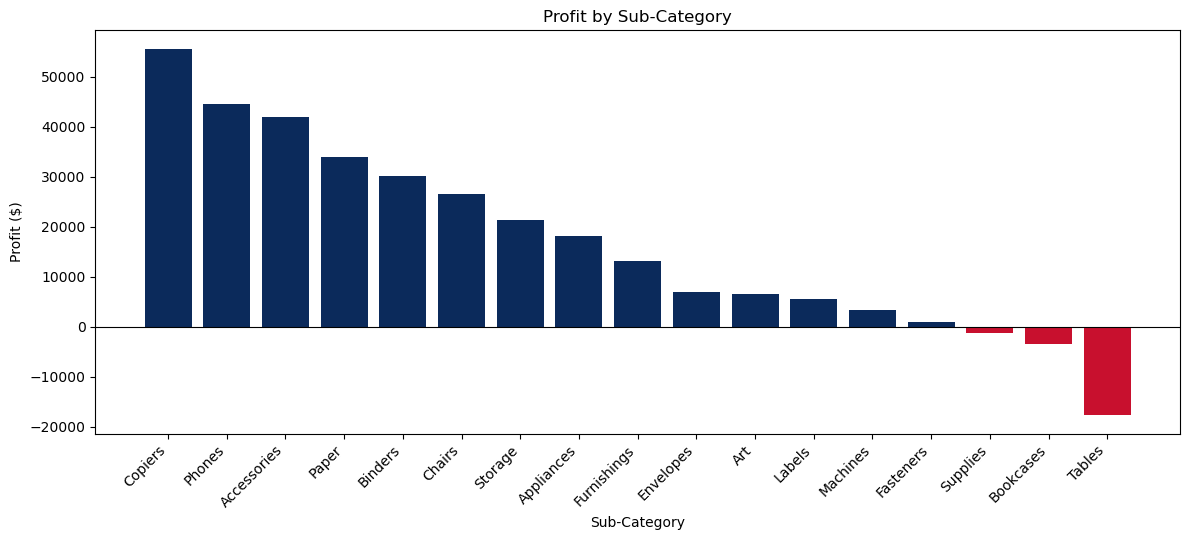

In [7]:
# Profit by sub-category (losses in red)
profit_by_sub = subcategory_analysis.sort_values('Profit', ascending=False)
bar_colors = ['#C8102E' if v < 0 else '#0B2A5B' for v in profit_by_sub['Profit']]

plt.figure(figsize=(12, 5.5))
plt.bar(profit_by_sub['Sub-Category'], profit_by_sub['Profit'], color=bar_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** **Phones** ($330K) and **Chairs** ($328K) have the highest sales, but Chairs earns only an 8.11% margin. **Copiers** earn the most profit ($55.6K, 37.20% margin). **Machines** sell $189K but earn only a 1.79% margin. Three sub-categories lose money: **Tables (-$17.7K)**, **Bookcases (-$3.5K)** and **Supplies (-$1.2K)**.

## 7. Region Analysis

    Region        Sales       Profit  Quantity  Profit_Margin
0  Central  500782.8528   39655.8752      8768           7.92
1     East  678435.1960   91506.3092     10609          13.49
2    South  391721.9050   46749.4303      6209          11.93
3     West  725255.6365  108329.8079     12234          14.94


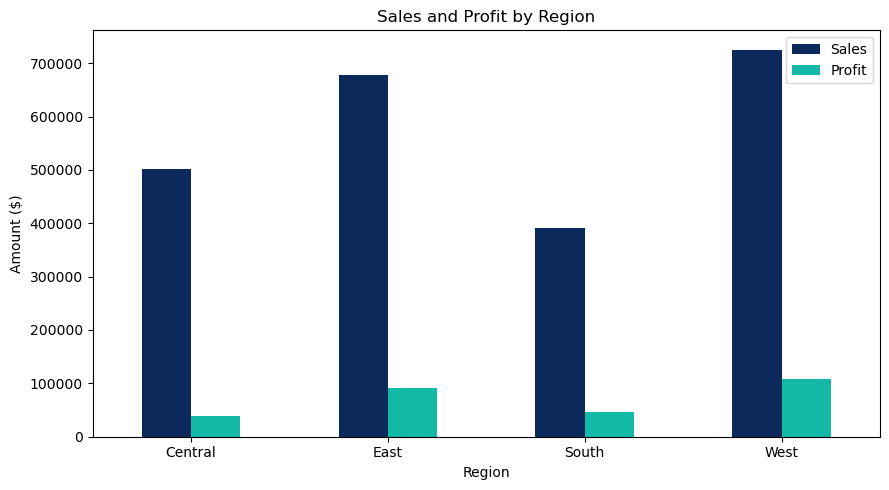

In [8]:
region_analysis = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

region_analysis['Profit_Margin'] = (
    region_analysis['Profit'] /
    region_analysis['Sales'] * 100
).round(2)

print(region_analysis)

# Visualization
region_analysis.plot(
    x='Region',
    y=['Sales', 'Profit'],
    kind='bar',
    figsize=(9, 5),
    color=['#0B2A5B', '#14B8A6']
)

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** **West** ($725K sales, 14.94% margin) and **East** ($678K sales, 13.49% margin) lead. **Central** sells $501K but earns only $40K (**7.92% margin**), which is less profit than **South** ($47K) even though South sells less ($392K).

## 8. Top Sub-Categories and Cities

In [9]:
# Top 5 sub-categories by sales
top_sales = subcategory_analysis.sort_values(
    'Sales',
    ascending=False
).head(5)

# Bottom 5 sub-categories by profit
bottom_profit = subcategory_analysis.sort_values(
    'Profit',
    ascending=True
).head(5)

print("TOP 5 SUB-CATEGORIES BY SALES")
display(top_sales[['Sub-Category', 'Sales', 'Profit']])

print("\nBOTTOM 5 SUB-CATEGORIES BY PROFIT")
display(bottom_profit[['Sub-Category', 'Sales', 'Profit']])

# Top 10 cities by sales
top_cities = df.groupby('City').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

top_cities = top_cities.sort_values(
    'Sales',
    ascending=False
).head(10)

print("\nTOP 10 CITIES BY SALES")
display(top_cities)

TOP 5 SUB-CATEGORIES BY SALES


,Sub-Category,Sales,Profit
13,Phones,330007.054,44515.7306
5,Chairs,327777.761,26567.1278
14,Storage,223843.608,21278.8264
16,Tables,206965.532,-17725.4811
3,Binders,203409.169,30228.0003



BOTTOM 5 SUB-CATEGORIES BY PROFIT


,Sub-Category,Sales,Profit
16,Tables,206965.5320,-17725.4811
4,Bookcases,114879.9963,-3472.5560
15,Supplies,46673.5380,-1189.0995
8,Fasteners,3024.2800,949.5182
11,Machines,189238.6310,3384.7569



TOP 10 CITIES BY SALES


,City,Sales,Profit
329,New York City,256319.0410,62013.8973
266,Los Angeles,175831.9010,30431.4267
452,Seattle,119460.2820,29121.6825
438,San Francisco,112577.1720,17466.1186
374,Philadelphia,109061.4610,-13843.2106
207,Houston,64441.2564,-10175.1755
80,Chicago,48535.9770,-6648.3318
437,San Diego,47521.0290,6377.1960
216,Jacksonville,44713.1830,-2323.8350
464,Springfield,43054.3420,6200.6974


In [10]:
# Which of the top 10 cities by sales lose money?
top_cities['Result'] = top_cities['Profit'].apply(
    lambda value: 'Loss' if value < 0 else 'Profit'
)

display(top_cities.round(2))

loss_cities = top_cities[top_cities['Profit'] < 0]
print(f"Top-10 cities by sales that lose money: {len(loss_cities)}")
print(", ".join(loss_cities['City']))

,City,Sales,Profit,Result
329,New York City,256319.04,62013.90,Profit
266,Los Angeles,175831.90,30431.43,Profit
452,Seattle,119460.28,29121.68,Profit
438,San Francisco,112577.17,17466.12,Profit
374,Philadelphia,109061.46,-13843.21,Loss
207,Houston,64441.26,-10175.18,Loss
80,Chicago,48535.98,-6648.33,Loss
437,San Diego,47521.03,6377.20,Profit
216,Jacksonville,44713.18,-2323.84,Loss
464,Springfield,43054.34,6200.70,Profit


Top-10 cities by sales that lose money: 4
Philadelphia, Houston, Chicago, Jacksonville


**Insight:** **New York City** is the top city ($256K sales, $62K profit). However, **4 of the top 10 cities by sales lose money**: Philadelphia (-$13.8K), Houston (-$10.2K), Chicago (-$6.6K) and Jacksonville (-$2.3K). High sales do not guarantee profit.

## 9. Key Business Insights

In [11]:
top_category = category_analysis.loc[
    category_analysis['Sales'].idxmax(), 'Category'
]

top_segment = segment_analysis.loc[
    segment_analysis['Sales'].idxmax(), 'Segment'
]

top_subcategory = subcategory_analysis.loc[
    subcategory_analysis['Sales'].idxmax(), 'Sub-Category'
]

worst_subcategory = subcategory_analysis.loc[
    subcategory_analysis['Profit'].idxmin(), 'Sub-Category'
]

print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print(f"• {top_segment} is the largest sales segment.")
print(f"• {top_category} generates the highest category sales.")
print(f"• {top_subcategory} has the highest sub-category sales.")
print(f"• {worst_subcategory} has the lowest profitability.")
print(f"• Overall profit margin is {profit_margin:.2f}%.")

KEY BUSINESS INSIGHTS
• Consumer is the largest sales segment.
• Technology generates the highest category sales.
• Phones has the highest sub-category sales.
• Tables has the lowest profitability.
• Overall profit margin is 12.47%.


### Conclusion
- **Technology** and **Office Supplies** drive profit (about 17% margin each), while **Furniture** (2.49%) is weak because of **Tables**.
- **Central** region and several large cities (Philadelphia, Houston, Chicago) sell a lot but earn little or lose money.
- **Consumer** is the largest segment, but **Home Office** has the best margin.
- The strongest finding, the effect of discounts above 20% (about $135K in losses), is analyzed in `02_Exploratory_Data_Analysis.ipynb` and in the SQL queries 16 and 17.